In [4]:
import numpy as np
import pandas as pd
from galpy.orbit import Orbit
from galpy.potential import MWPotential2014
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm


In [5]:
# NASA exoplanet archive
nasa = pd.read_csv("NASA exoplanet Archive (filtered Columns) 1 (Degrees).csv",
                   skiprows=30)
nasa = nasa[nasa["gaia_dr3_id"].notna()].copy()
nasa["gaia_id_clean"] = (nasa["gaia_dr3_id"]
                         .astype(str)
                         .str.replace("Gaia DR3 ", "", regex=False)
                         .str.strip())

## Drop fully identical rows, keep one per Gaia ID
nasa = nasa.drop_duplicates(subset="gaia_id_clean", keep="first")
nasa_ids = set(nasa["gaia_id_clean"])

# LAMOST MRS: RV + parameters
rv    = pd.read_csv("lamost_mrs_rv.csv")
pars  = pd.read_csv("lamost_mrs_params.csv")


for df in (rv, pars):
    df["gaia_id_clean"] = df["gaia_source_id"].astype(str).str.strip()

In [6]:
#save first 200 rows of each file as CSV for inspection
rv.head(200).to_csv("rv_sample_50.csv", index=False)
pars.head(200).to_csv("pars_sample_50.csv", index=False)

In [7]:
# choose the best observation per star using SNR, before any merge
rv = (rv.sort_values("snr", ascending=False)
        .drop_duplicates(subset="gaia_id_clean", keep="first"))

pars = (pars.sort_values("snr", ascending=False)
          .drop_duplicates(subset="gaia_id_clean", keep="first"))

In [8]:
#Join LAMOST RV + Parameters
lamost_all = pd.merge(
    rv, pars,
    on="gaia_id_clean", how="outer",
    suffixes=("_rv", "_param")
)
print(f"LAMOST combined: {len(lamost_all):,}")


#Combined NASA + LAMOST file (inner join on Gaia ID)
nasa_lamost = nasa.merge(
    lamost_all,
    on="gaia_id_clean",
    how="inner"
)
print(f"Combined NASA + LAMOST: {len(nasa_lamost):,} rows")

# Standard LAMOST alpha elements relative to Fe
alpha_cols     = ['mg_fe', 'si_fe', 'ca_fe', 'ti_fe']

# Compute mean across the 4 elements row-wise (
nasa_lamost['ALPHA_FE']     = nasa_lamost[alpha_cols].mean(axis=1)
lamost_all['ALPHA_FE']     = lamost_all[alpha_cols].mean(axis=1)

LAMOST combined: 2,004,298
Combined NASA + LAMOST: 405 rows


In [9]:
# Save full LAMOST catalog
lamost_all.to_csv("lamost_mrs_full_catalog.csv", index=False)
print("Saved lamost_mrs_full_catalog.csv")

#save matched NASA + LAMOST file
nasa_lamost.to_csv("exoplanet_hosts_lamost_NASA_matched.csv", index=False)
print("Saved exoplanet_hosts_lamost_mrs_matched.csv")

Saved lamost_mrs_full_catalog.csv
Saved exoplanet_hosts_lamost_mrs_matched.csv


In [10]:
#Quality cuts on combined file
#Not removing null data as some of these are just missing values, not necessarily bad data.
nasa_lamost = nasa_lamost.replace(-9999, np.nan)
clean_hosts = nasa_lamost[
    (nasa_lamost["snr_rv"].isna()          | (nasa_lamost["snr_rv"] > 20)) &
    (nasa_lamost["rv_br_flag_rv"].isna()   | (nasa_lamost["rv_br_flag_rv"] == 0)) &
    (nasa_lamost["fibermask_param"].isna()       | (nasa_lamost["fibermask_param"] == 0)) &
    (nasa_lamost["teff_cnn"].isna()        | (nasa_lamost["teff_cnn"].between(3500, 5500)))
].copy()

print(f"After quality cuts: {len(clean_hosts):,} rows")
print(f"Retention: {100 * len(clean_hosts) / len(nasa_lamost):.1f}%")

#Quality cuts on full LAMOST combined file
lamost_all = pd.read_csv("lamost_mrs_full_catalog.csv")
lamost_all = lamost_all.replace(-9999, np.nan)

lamost_clean = lamost_all[
    (lamost_all["snr_rv"].isna()          | (lamost_all["snr_rv"] > 20)) &
    (lamost_all["rv_br_flag_rv"].isna()   | (lamost_all["rv_br_flag_rv"] == 0)) &
    (lamost_all["fibermask_param"].isna()       | (lamost_all["fibermask_param"] == 0)) &
    (lamost_all["teff_cnn"].isna()        | (lamost_all["teff_cnn"].between(3500, 5500)))
].copy()

print(f"After quality cuts: {len(lamost_clean):,} rows")
print(f"Retention: {100 * len(lamost_clean) / len(lamost_all):.1f}%")

After quality cuts: 186 rows
Retention: 45.9%
After quality cuts: 838,514 rows
Retention: 41.8%


In [11]:
#Orbit integration
orbit_sample = clean_hosts[clean_hosts["rv_br1_rv"].notna()].copy().reset_index(drop=True)
n = len(orbit_sample)
print(f"Stars with valid RV: {n}")

# Initialise arrays
v_x_galcen     = np.full(n, np.nan)
v_y_galcen     = np.full(n, np.nan)
v_z_galcen     = np.full(n, np.nan)
v_total_galcen = np.full(n, np.nan)
Lz             = np.full(n, np.nan)
ecc            = np.full(n, np.nan)
E              = np.full(n, np.nan)
X_galcen       = np.full(n, np.nan)
Y_galcen       = np.full(n, np.nan)
Z_galcen       = np.full(n, np.nan)

for i in range(n):
    try:
        o = Orbit(
            [
                orbit_sample["ra"].iloc[i],
                orbit_sample["dec"].iloc[i],
                1.0 / orbit_sample["sy_plx"].iloc[i],
                orbit_sample["sy_pmra"].iloc[i],
                orbit_sample["sy_pmdec"].iloc[i],
                orbit_sample["rv_br1_rv"].iloc[i],
            ],
            radec=True, solarmotion="schoenrich", ro=8.0, vo=220,
        )
        v_x_galcen[i]     = o.vx(use_physical=True)
        v_y_galcen[i]     = o.vy(use_physical=True)
        v_z_galcen[i]     = o.vz(use_physical=True)
        v_total_galcen[i] = np.sqrt(v_x_galcen[i]**2 + v_y_galcen[i]**2 + v_z_galcen[i]**2)
        Lz[i]             = o.Lz(use_physical=True)
        ecc[i]            = o.e(use_physical=True, pot=MWPotential2014, analytic=True)
        E[i]              = o.E(use_physical=True, pot=MWPotential2014)
        X_galcen[i]       = o.x(use_physical=True)
        Y_galcen[i]       = o.y(use_physical=True)
        Z_galcen[i]       = o.z(use_physical=True)

    except Exception as e:
        print(f"Error at star {i}: {e}")

print(f"Orbits computed for {(~np.isnan(Lz)).sum()} / {n} stars")

# Add orbit columns to orbit_sample
orbit_sample["v_x_galcen"]     = v_x_galcen
orbit_sample["v_y_galcen"]     = v_y_galcen
orbit_sample["v_z_galcen"]     = v_z_galcen
orbit_sample["v_total_galcen"] = v_total_galcen
orbit_sample["Lz_orbit"]       = Lz
orbit_sample["e_orbit"]        = ecc
orbit_sample["E_orbit"]        = E
orbit_sample["X_galcen"]       = X_galcen
orbit_sample["Y_galcen"]       = Y_galcen
orbit_sample["Z_galcen"]       = Z_galcen

#Merge orbit columns back into clean_hosts (NaN for stars without RV)
orbit_cols = ["gaia_id_clean", "v_x_galcen", "v_y_galcen", "v_z_galcen",
              "v_total_galcen", "Lz_orbit", "e_orbit", "E_orbit",
              "X_galcen", "Y_galcen", "Z_galcen"]

clean_hosts = clean_hosts.merge(orbit_sample[orbit_cols], on="gaia_id_clean", how="left")


clean_hosts.to_csv("exoplanet_hosts_lamost_mrs_with_orbits.csv", index=False)
print("Saved exoplanet_hosts_lamost_mrs_with_orbits.csv")

Stars with valid RV: 177
Orbits computed for 176 / 177 stars
Saved exoplanet_hosts_lamost_mrs_with_orbits.csv


In [12]:
# MONTE CARLO UNCERTAINTIES FOR TOOMRE DIAGRAM ONLY

N_MC = 1000

vygalcen    = np.full(n, np.nan)
vy_err      = np.full(n, np.nan)
vperp       = np.full(n, np.nan)
vperp_err   = np.full(n, np.nan)

for i in range(n):
    try:
        row = orbit_sample.iloc[i]
        vxs, vys, vzs = [], [], []

        plx_samples  = np.random.normal(row['sy_plx'],   row['sy_plxerr1'],   N_MC)
        pmra_samples = np.random.normal(row['sy_pmra'],  row['sy_pmraerr1'],  N_MC)
        pmde_samples = np.random.normal(row['sy_pmdec'], row['sy_pmdecerr1'], N_MC)
        rv_samples   = np.random.normal(row['rv_b1'],    row['rv_b1_err'],    N_MC)

        for j in range(N_MC):
            if plx_samples[j] <= 0:
                continue
            try:
                o = Orbit(
                    [row['ra'], row['dec'],
                     1.0 / plx_samples[j],
                     pmra_samples[j], pmde_samples[j], rv_samples[j]],
                    radec=True, solarmotion='schoenrich', ro=8.0, vo=220,
                )
                vxs.append(o.vx(use_physical=True))
                vys.append(o.vy(use_physical=True))
                vzs.append(o.vz(use_physical=True))
            except Exception:
                continue

        if len(vys) < 10:
            continue

        # Vy: median + 1-sigma from 16th/84th percentiles
        p16, p50, p84 = np.percentile(vys, [16, 50, 84])
        vygalcen[i] = p50
        vy_err[i]   = (p84 - p16) / 2

        # Vperp = sqrt(Vx^2 + Vz^2): median + uncertainty
        vperp_arr = np.sqrt(np.array(vxs)**2 + np.array(vzs)**2)
        p16, p50, p84 = np.percentile(vperp_arr, [16, 50, 84])
        vperp[i]     = p50
        vperp_err[i] = (p84 - p16) / 2

    except Exception as e:
        print(f"Error at star {i}: {e}")

# Attach to orbit_sample
orbit_sample['vygalcen']  = vygalcen
orbit_sample['vy_err']    = vy_err
orbit_sample['vperp']     = vperp
orbit_sample['vperp_err'] = vperp_err

# Per-survey uncertainty summary
valid = ~np.isnan(vy_err)
print("  LAMOST — Toomre Diagram Kinematic Uncertainties")
print(f"  N stars with valid MC runs : {valid.sum()} / {n}")
print(f"  Median sigma(V_Y)              : {np.nanmedian(vy_err):.3f} km/s")
print(f"  Median sigma(V_perp)           : {np.nanmedian(vperp_err):.3f} km/s")



  LAMOST — Toomre Diagram Kinematic Uncertainties
  N stars with valid MC runs : 157 / 177
  Median sigma(V_Y)              : 0.737 km/s
  Median sigma(V_perp)           : 0.782 km/s


 plot1_alpha_feh.png


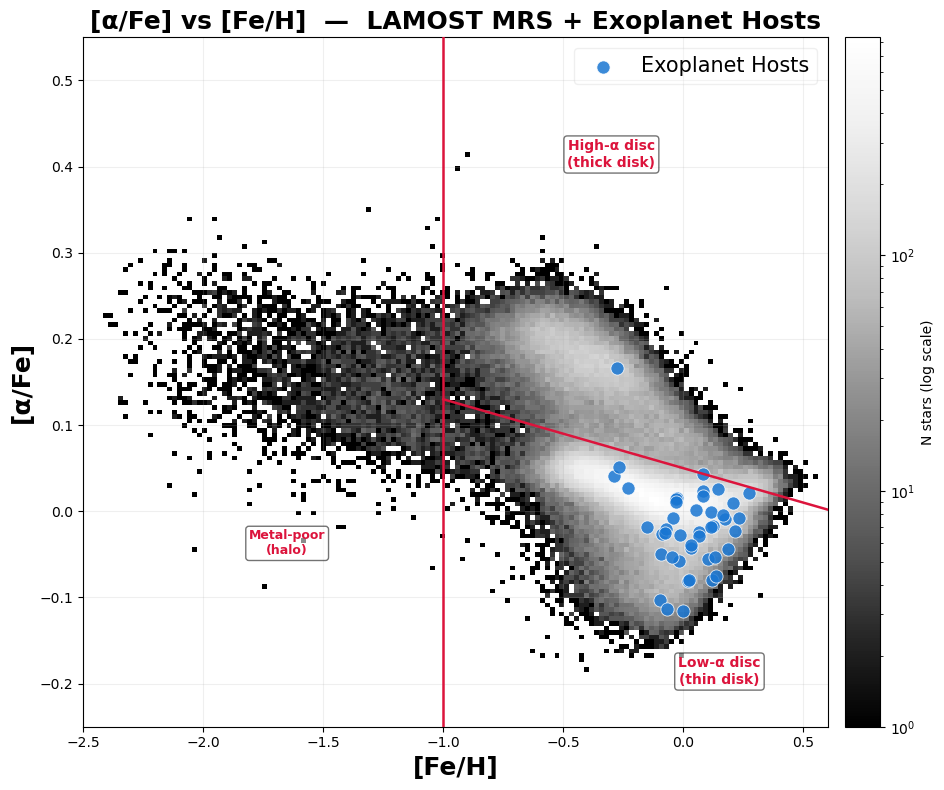

 plot2_toomre.png


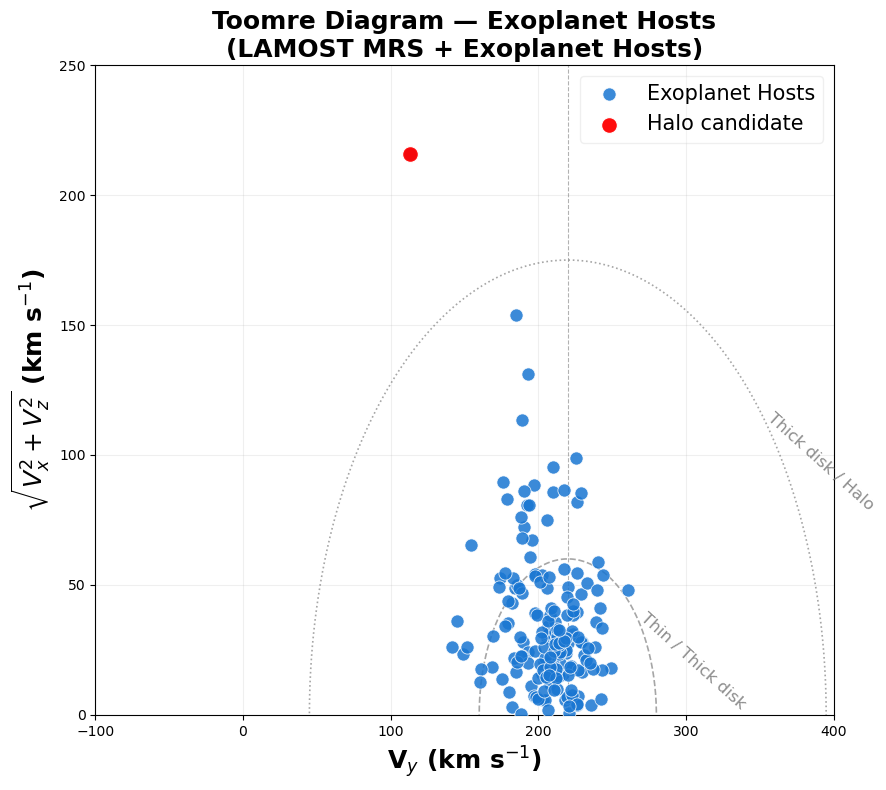

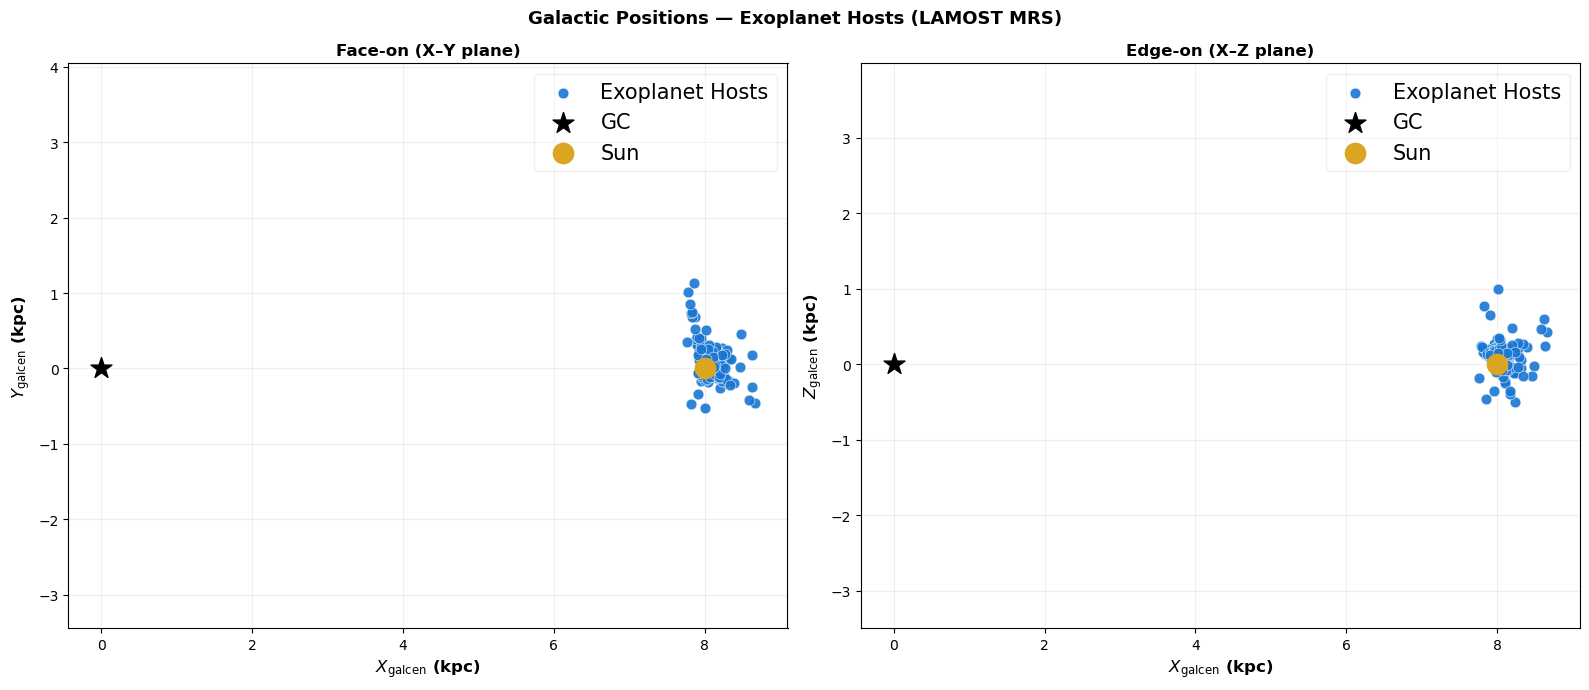

In [14]:


#Boundary definitions
FEH_CUT    = -1.0    # vertical line separating metal-poor halo from in-situ disc
DIAG_SLOPE = -0.08  # slope of the high alpha / low alpha diagonal boundary
DIAG_INT   =  0.05   # intercept


# PLOT 1 - chemical abundance space

bg = lamost_clean.dropna(subset=["feh_cnn", "ALPHA_FE"]) 

fig, ax = plt.subplots(figsize=(10, 8))
h = ax.hist2d(bg["feh_cnn"], bg["ALPHA_FE"],
              bins=150, range=[[-2.5, 0.6], [-0.25, 0.55]],
              cmap="Greys_r", norm=LogNorm(), zorder=1)
plt.colorbar(h[3], ax=ax, label="N stars (log scale)", pad=0.02)

g = clean_hosts.dropna(subset=["feh_cnn", "ALPHA_FE"])
ax.scatter(g["feh_cnn"], g["ALPHA_FE"],
           c="#1976d2", marker="o",
           s=90, edgecolors="white", linewidths=0.6,
           zorder=5, alpha=0.85,
           label=f"Exoplanet Hosts")

# 1) Vertical cut
ax.axvline(FEH_CUT, color='crimson', lw=1.8, ls='-', zorder=6)

# 2) Diagonal cut — drawn only for [Fe/H] ≥ FEH_CUT
feh_diag = np.linspace(FEH_CUT, 0.6, 300)
ax.plot(feh_diag, DIAG_SLOPE * feh_diag + DIAG_INT,
        color='crimson', lw=1.8, ls='-', zorder=6)

# Region labels
ax.text(-0.3,  0.40, 'High-α disc\n(thick disk)',
        color='crimson', fontsize=10, fontweight='bold', ha='center',
        bbox=dict(boxstyle='round,pad=0.25', fc='white', alpha=0.55))
ax.text( 0.15, -0.2, 'Low-α disc\n(thin disk)',
        color='crimson', fontsize=10, fontweight='bold', ha='center',
        bbox=dict(boxstyle='round,pad=0.25', fc='white', alpha=0.55))
ax.text(-1.65, -0.05, 'Metal-poor\n(halo)',
        color='crimson', fontsize=9,  fontweight='bold', ha='center',
        bbox=dict(boxstyle='round,pad=0.25', fc='white', alpha=0.55))

ax.set_xlabel("[Fe/H]", fontsize=18, fontweight="bold")
ax.set_ylabel("[α/Fe]", fontsize=18, fontweight="bold")
ax.set_title(f"[α/Fe] vs [Fe/H]  —  LAMOST MRS + Exoplanet Hosts",
             fontsize=18, fontweight="bold")
ax.legend(fontsize=15, framealpha=0.3)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig("plot1_alpha_feh.png", dpi=300, bbox_inches="tight")
print(" plot1_alpha_feh.png")
plt.show()


# PLOT 2 — Toomre Diagram

clean_hosts["V_perp"] = np.sqrt(
    clean_hosts["v_x_galcen"]**2 + clean_hosts["v_z_galcen"]**2
)
clean_hosts = clean_hosts.dropna(subset=['V_perp'])
halo_mask = g["V_perp"] > 175.0
g_halo  = g[halo_mask]

V_LSR = 220.0

fig, ax = plt.subplots(figsize=(9, 8))

g = clean_hosts.dropna(subset=["v_y_galcen", "V_perp"])
ax.scatter(g["v_y_galcen"], g["V_perp"],
           c="#1976d2", marker="o",
           s=90, edgecolors="white", linewidths=0.6,
           zorder=5, alpha=0.85,
           label=f"Exoplanet Hosts")

for v_bound, ls, pop_label in [(60, "--", "Thin / Thick disk"), (175, ":", "Thick disk / Halo")]:
    theta = np.linspace(-1, np.pi, 300)  # upper half only since y >= 0
    ax.plot(V_LSR + v_bound*np.cos(theta),
            v_bound*np.sin(theta),
            color="grey", ls=ls, lw=1.2, alpha=0.7)
    # Place label on the arc at chosen angle
    angle_deg = 42
    angle_rad = np.radians(angle_deg)
    lx = V_LSR + v_bound * np.cos(angle_rad)
    ly = v_bound * np.sin(angle_rad)
    ax.text(lx + 3, ly, pop_label,
            color="grey", fontsize=12, alpha=0.9,
            rotation=-angle_deg,
            ha="left", va="top")
    
halo_mask = g["V_perp"] > 175.0
g_halo  = g[halo_mask]

#PLOT HALO CANDIDATE (RED, ON TOP)
ax.scatter(g_halo["v_y_galcen"], g_halo["V_perp"],
           c="red", marker="o",
           s=130, edgecolors="white", linewidths=0.9,
           zorder=6, alpha=0.95,
           label="Halo candidate")


ax.axvline(V_LSR, color="grey", lw=0.8, alpha=0.6, ls="--")
ax.set_ylim(0,250)
ax.set_xlim(-100,400)
ax.set_xlabel("V$_y$ (km s$^{-1}$)", fontsize=18, fontweight="bold")
ax.set_ylabel(r"$\sqrt{V_x^2 + V_z^2}$ (km s$^{-1}$)", fontsize=18, fontweight="bold")
ax.set_title("Toomre Diagram — Exoplanet Hosts\n(LAMOST MRS + Exoplanet Hosts)",
             fontsize=18, fontweight="bold")
ax.legend(fontsize=15, framealpha=0.3)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig("plot2_toomre_poster.png", dpi=300, bbox_inches="tight")
print(" plot2_toomre.png")
plt.show()


# PLOT 3 — Galactic positions: X–Y (face-on) and X–Z (edge-on) planes


hvalid = clean_hosts.dropna(subset=['X_galcen', 'Y_galcen', 'Z_galcen'])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

panels = [
    ('X_galcen', 'Y_galcen', r'$X_\mathrm{galcen}$ (kpc)', r'$Y_\mathrm{galcen}$ (kpc)', 'Face-on (X–Y plane)'),
    ('X_galcen', 'Z_galcen', r'$X_\mathrm{galcen}$ (kpc)', r'$Z_\mathrm{galcen}$ (kpc)', 'Edge-on (X–Z plane)'),
]

for ax, (xcol, ycol, xlabel, ylabel, title) in zip(axes, panels):
    ax.scatter(hvalid[xcol], hvalid[ycol],
               c='#1976d2', marker='o', s=60,
               edgecolors='white', linewidths=0.4,
               alpha=0.9, zorder=4, label='Exoplanet Hosts')

    ax.scatter(0, 0, c='black',      s=250, marker='*', zorder=10, label='GC')
    ax.scatter(8.0, 0, c='goldenrod', s=200, marker='o', zorder=10,
               linewidths=1.5, label='Sun')

    ax.set_xlabel(xlabel, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
    ax.set_title(title,   fontsize=12, fontweight='bold')
    ax.legend(fontsize=15, framealpha=0.3)
    ax.grid(True, alpha=0.2)
    ax.set_aspect('equal', adjustable='datalim')

fig.suptitle('Galactic Positions — Exoplanet Hosts (LAMOST MRS)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot3galacticposition.png', dpi=300, bbox_inches='tight')
plt.show()

In [18]:
# Classification

#CHEMICAL
chem = clean_hosts.dropna(subset=['feh_cnn', 'ALPHA_FE']).copy()
n_chem = len(chem)

def chem_class(feh, alpha):
    if feh < FEH_CUT:
        return 'Halo (metal-poor)'
    elif alpha > DIAG_SLOPE * feh + DIAG_INT:
        return 'Thick disc (high-alpha)'
    else:
        return 'Thin disc (low-α)'

chem['chem_pop'] = chem.apply(lambda r: chem_class(r['feh_cnn'], r['ALPHA_FE']), axis=1)

print(f"Stars with valid [Fe/H] & [Alpha/Fe]: {n_chem}\n")
for label, grp in chem.groupby('chem_pop'):
    pct = 100 * len(grp) / n_chem
    print(f"  {label:<25}  N={len(grp):>4}  ({pct:.1f}%)")

#KINEMATIC (Toomre velocity cuts)
VLSR         = 220.0  
V_THIN_THICK =  60.0  
V_THICK_HALO = 175.0 

kin = clean_hosts.dropna(subset=['v_x_galcen', 'v_y_galcen', 'v_z_galcen']).copy()
n_kin = len(kin)

kin['V_perp']   = np.sqrt(kin['v_x_galcen']**2 + kin['v_z_galcen']**2)
kin['V_toomre'] = np.sqrt((kin['v_y_galcen'] - VLSR)**2 + kin['V_perp']**2)

def kin_class(v):
    if v < V_THIN_THICK:
        return 'Thin disc'
    elif v < V_THICK_HALO:
        return 'Thick disc'
    else:
        return 'Halo'

kin['kin_pop'] = kin['V_toomre'].apply(kin_class)

print(" KINEMATIC CLASSIFICATION (Toomre)")
print(f"Stars with valid kinematics: {n_kin}\n")
for label, grp in kin.groupby('kin_pop'):
    pct = 100 * len(grp) / n_kin
    print(f"  {label:<12}  N={len(grp):>4}  ({pct:.1f}%)")

Stars with valid [Fe/H] & [Alpha/Fe]: 112

  Thick disc (high-alpha)    N=   1  (0.9%)
  Thin disc (low-α)          N= 111  (99.1%)
 KINEMATIC CLASSIFICATION (Toomre)
Stars with valid kinematics: 176

  Halo          N=   1  (0.6%)
  Thick disc    N=  36  (20.5%)
  Thin disc     N= 139  (79.0%)
